# Transformer attention training-speed benchmark

## Goal

Compare the training speed of the four combinations below using synthetic tensors that enter directly at the transformer stack:

| Attention pattern | Reference backend | Optimized backend |
|---|---|---|
| cCRE-guided BigBird | dense masked `einsum` | FlexAttention on CUDA; masked SDPA on CPU/MPS |
| Full attention | dense `einsum` | PyTorch SDPA |

The convolutional stem, pooling tower, prediction heads, data loading, and distributed communication are intentionally excluded. Each timed training step includes transformer forward, loss calculation, backward, and an AdamW update.

## Setup

Run this notebook from an environment in which the project and notebook dependencies are installed:

```bash
python -m pip install -e .
python -m pip install jupyter
jupyter lab notebooks/transformer_attention_speed_benchmark.ipynb
```

For the intended FlexAttention comparison, use a CUDA GPU with PyTorch 2.5 or newer. On CPU or MPS, the cCRE optimized case automatically uses the repository's masked-SDPA fallback and the output labels make that fallback explicit.

In [2]:
from __future__ import annotations

import gc
import os
import platform
import statistics
import sys
import time
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "bigbird_enformer").is_dir():
            return candidate
    raise FileNotFoundError("Could not find src/bigbird_enformer from the current directory")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src"))

from bigbird_enformer.layers.attention import (
    BigBirdCCREAttention,
    BigBirdCCREAttentionEinsum,
    FullAttention,
    FullAttentionEinsum,
)
print(f"Repository: {REPO_ROOT}")
print(f"Python:     {platform.python_version()}")
print(f"PyTorch:    {torch.__version__}")

Repository: /Users/lishen/proj/Bigbird-Enformer
Python:     3.12.13
PyTorch:    2.13.0


### Benchmark parameters

Set `PROFILE_NAME` in the next cell, then run that cell and everything below it. The default `quick` profile is suitable for checking scaling without instantiating the full model. Use `enformer` for the production transformer shape (11 blocks, width 1536, length 1536). The environment variable `ATTENTION_BENCH_PROFILE` can still override the interactive choice for automated runs.

Key assumptions:

- All four cases use the same two-residual transformer wrapper, mirroring `TransformerBlock` in `src/bigbird_enformer/models/enformer_plus.py`; the four attention classes are imported directly from the repository.
- Attention and residual dropout are zero to reduce timing noise and satisfy FlexAttention's no-post-softmax-dropout constraint.
- Synthetic cCRE masks select the same fraction as `mean_ccre_k: 460` at transformer length 1536 in `configs/ccre_bigbird.yaml`.
- One process and one device are measured. Data loading, convolutional features, classifiers, DDP, and gradient accumulation are out of scope.
- The input requires gradients, so backward includes the gradient passed toward the omitted convolutional trunk.

In [3]:
# Choose one: "smoke", "quick", or "enformer".
PROFILE_NAME = "quick"
PROFILE_NAME

'quick'

In [4]:
@dataclass(frozen=True)
class BenchmarkProfile:
    dim: int
    depth: int
    heads: int
    dim_key: int
    dim_value: int
    block_size: int
    batch_size: int
    sequence_lengths: tuple[int, ...]
    warmup_steps: int
    timed_steps: int


PROFILES = {
    "smoke": BenchmarkProfile(
        dim=64,
        depth=1,
        heads=4,
        dim_key=16,
        dim_value=16,
        block_size=64,
        batch_size=1,
        sequence_lengths=(128,),
        warmup_steps=1,
        timed_steps=3,
    ),
    "quick": BenchmarkProfile(
        dim=256,
        depth=2,
        heads=8,
        dim_key=32,
        dim_value=32,
        block_size=128,
        batch_size=1,
        sequence_lengths=(512, 1024, 1536),
        warmup_steps=2,
        timed_steps=5,
    ),
    "enformer": BenchmarkProfile(
        dim=1536,
        depth=11,
        heads=8,
        dim_key=64,
        dim_value=192,
        block_size=128,
        batch_size=1,
        sequence_lengths=(1536, 3072, 6144, 12288),
        warmup_steps=3,
        timed_steps=10,
    ),
}

PROFILE_NAME = os.getenv("ATTENTION_BENCH_PROFILE", PROFILE_NAME)
if PROFILE_NAME not in PROFILES:
    raise ValueError(f"Unknown profile {PROFILE_NAME!r}; choose from {tuple(PROFILES)}")

PROFILE = PROFILES[PROFILE_NAME]
SEED = 888
CCRE_GLOBAL_FRACTION = 153 / 1536
LEARNING_RATE = 5e-4

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if DEVICE.type == "cuda":
    COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
elif DEVICE.type == "mps":
    COMPUTE_DTYPE = torch.float16
else:
    COMPUTE_DTYPE = torch.float32

CCRE_OPTIMIZED_BACKEND = "FlexAttention" if DEVICE.type == "cuda" else "masked SDPA fallback"

environment = {
    "profile": PROFILE_NAME,
    "device": str(DEVICE),
    "device_name": torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else platform.machine(),
    "compute_dtype": str(COMPUTE_DTYPE).replace("torch.", ""),
    "ccre_optimized_backend": CCRE_OPTIMIZED_BACKEND,
    **asdict(PROFILE),
}
display(pd.Series(environment, name="value").to_frame())

for length in PROFILE.sequence_lengths:
    if length % PROFILE.block_size:
        raise ValueError(f"sequence length {length} must be divisible by block size {PROFILE.block_size}")

,value
profile,quick
device,mps
device_name,arm64
compute_dtype,float16
ccre_optimized_backend,masked SDPA fallback
dim,256
depth,2
heads,8
dim_key,32
dim_value,32


## Steps

### 1. Build comparable transformer stacks

The only difference between cases is the attention class/backend. Re-seeding each build gives all cases matching initial parameter values.

In [5]:
@dataclass(frozen=True)
class AttentionCase:
    label: str
    pattern: str
    requested_backend: str
    effective_backend: str


class TransformerBlock(torch.nn.Module):
    """Dependency-light mirror of the repository's production transformer block."""

    def __init__(self, dim: int, attention: torch.nn.Module, dropout_rate: float = 0.0):
        super().__init__()
        self.norm1 = torch.nn.LayerNorm(dim)
        self.attention = attention
        self.residual_dropout = torch.nn.Dropout(dropout_rate)
        self.norm2 = torch.nn.LayerNorm(dim)
        self.feed_forward = torch.nn.Sequential(
            torch.nn.Linear(dim, dim * 2),
            torch.nn.Dropout(dropout_rate),
            torch.nn.ReLU(),
            torch.nn.Linear(dim * 2, dim),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, inputs: torch.Tensor, is_global: torch.Tensor | None = None) -> torch.Tensor:
        hidden = inputs + self.residual_dropout(
            self.attention(self.norm1(inputs), is_global=is_global)
        )
        return hidden + self.feed_forward(self.norm2(hidden))


CASES = (
    AttentionCase("cCRE + einsum", "ccre_bigbird", "einsum", "einsum"),
    AttentionCase("cCRE + optimized", "ccre_bigbird", "auto", CCRE_OPTIMIZED_BACKEND),
    AttentionCase("Full + einsum", "full", "einsum", "einsum"),
    AttentionCase("Full + SDPA", "full", "sdpa", "SDPA"),
)


class TransformerStack(torch.nn.Module):
    def __init__(self, blocks: list[TransformerBlock]):
        super().__init__()
        self.blocks = torch.nn.ModuleList(blocks)

    def forward(self, inputs: torch.Tensor, is_global: torch.Tensor | None = None) -> torch.Tensor:
        hidden = inputs
        for block in self.blocks:
            hidden = block(hidden, is_global=is_global)
        return hidden


def build_stack(case: AttentionCase, profile: BenchmarkProfile) -> TransformerStack:
    torch.manual_seed(SEED)
    blocks = []
    for _ in range(profile.depth):
        common = dict(
            dim=profile.dim,
            heads=profile.heads,
            dim_key=profile.dim_key,
            dim_value=profile.dim_value,
            dropout=0.0,
        )
        if case.pattern == "ccre_bigbird" and case.requested_backend == "einsum":
            attention = BigBirdCCREAttentionEinsum(**common, block_size=profile.block_size)
        elif case.pattern == "ccre_bigbird":
            attention = BigBirdCCREAttention(
                **common,
                block_size=profile.block_size,
                backend=case.requested_backend,
            )
        elif case.requested_backend == "einsum":
            attention = FullAttentionEinsum(**common)
        else:
            attention = FullAttention(**common)
        blocks.append(TransformerBlock(profile.dim, attention, dropout_rate=0.0))
    return TransformerStack(blocks)


def make_ccre_mask(batch_size: int, sequence_length: int, device: torch.device) -> torch.Tensor:
    global_count = max(1, min(sequence_length, round(CCRE_GLOBAL_FRACTION * sequence_length)))
    generator = torch.Generator(device="cpu").manual_seed(SEED + sequence_length)
    scores = torch.rand(batch_size, sequence_length, generator=generator)
    selected = scores.topk(global_count, dim=1).indices
    mask = torch.zeros(batch_size, sequence_length, dtype=torch.bool)
    mask.scatter_(1, selected, True)
    return mask.to(device)


display(pd.DataFrame([asdict(case) for case in CASES]))

,label,pattern,requested_backend,effective_backend
0,cCRE + einsum,ccre_bigbird,einsum,einsum
1,cCRE + optimized,ccre_bigbird,auto,masked SDPA fallback
2,Full + einsum,full,einsum,einsum
3,Full + SDPA,full,sdpa,SDPA


### 2. Check paired implementations

Before timing, use shared weights and a small synthetic example to check full-einsum vs. full-SDPA and cCRE-einsum vs. the device's optimized path. This is a local reasonableness check, not a replacement for the repository test suite.

In [6]:
def compare_pair(reference_case: AttentionCase, optimized_case: AttentionCase) -> dict:
    check_length = 4 * PROFILE.block_size
    reference = build_stack(reference_case, PROFILE).to(DEVICE).eval()
    optimized = build_stack(optimized_case, PROFILE).to(DEVICE).eval()
    optimized.load_state_dict(reference.state_dict())

    generator = torch.Generator(device="cpu").manual_seed(SEED)
    inputs = torch.randn(1, check_length, PROFILE.dim, generator=generator).to(DEVICE)
    mask = make_ccre_mask(1, check_length, DEVICE) if reference_case.pattern == "ccre_bigbird" else None

    with torch.no_grad():
        expected = reference(inputs, is_global=mask)
        actual = optimized(inputs, is_global=mask)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        elif DEVICE.type == "mps":
            torch.mps.synchronize()

    difference = (actual.float() - expected.float()).abs()
    result = {
        "pair": f"{reference_case.label} vs {optimized_case.label}",
        "max_abs_difference": difference.max().item(),
        "mean_abs_difference": difference.mean().item(),
        "close": torch.allclose(actual.float(), expected.float(), rtol=2e-3, atol=2e-3),
    }
    del reference, optimized, inputs, expected, actual
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()
    return result


correctness = pd.DataFrame(
    [
        compare_pair(CASES[0], CASES[1]),
        compare_pair(CASES[2], CASES[3]),
    ]
)
display(correctness)
if not correctness["close"].all():
    raise AssertionError("A paired attention implementation exceeded the configured tolerance")

,pair,max_abs_difference,mean_abs_difference,close
0,cCRE + einsum vs cCRE + optimized,0.0,0.0,True
1,Full + einsum vs Full + SDPA,0.0,0.0,True


### 3. Time steady-state training steps

The first step is reported separately because the cCRE CUDA path compiles FlexAttention for each new shape. It is excluded from the steady-state median. Device synchronization brackets every measurement so asynchronous accelerator work is included.

In [7]:
def synchronize_device() -> None:
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elif DEVICE.type == "mps":
        torch.mps.synchronize()


def autocast_context():
    if DEVICE.type in {"cuda", "mps"}:
        return torch.autocast(device_type=DEVICE.type, dtype=COMPUTE_DTYPE)
    return nullcontext()


def clear_device_cache() -> None:
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()


def benchmark_case(case: AttentionCase, sequence_length: int) -> dict:
    clear_device_cache()
    torch.manual_seed(SEED)

    model = build_stack(case, PROFILE).to(DEVICE).train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    generator = torch.Generator(device="cpu").manual_seed(SEED + sequence_length)
    inputs = torch.randn(
        PROFILE.batch_size,
        sequence_length,
        PROFILE.dim,
        generator=generator,
    ).to(DEVICE)
    inputs.requires_grad_(True)
    is_global = (
        make_ccre_mask(PROFILE.batch_size, sequence_length, DEVICE)
        if case.pattern == "ccre_bigbird"
        else None
    )

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    def training_step() -> float:
        optimizer.zero_grad(set_to_none=True)
        inputs.grad = None
        synchronize_device()
        started = time.perf_counter()
        with autocast_context():
            outputs = model(inputs, is_global=is_global)
            loss = outputs.float().square().mean()
        loss.backward()
        optimizer.step()
        synchronize_device()
        return time.perf_counter() - started

    first_step_seconds = training_step()
    for _ in range(PROFILE.warmup_steps):
        training_step()

    step_seconds = [training_step() for _ in range(PROFILE.timed_steps)]
    median_seconds = statistics.median(step_seconds)
    peak_memory_mib = (
        torch.cuda.max_memory_allocated(DEVICE) / (1024**2)
        if DEVICE.type == "cuda"
        else np.nan
    )
    result = {
        "case": case.label,
        "attention_pattern": case.pattern,
        "backend": case.effective_backend,
        "sequence_length": sequence_length,
        "global_tokens_per_sample": int(is_global[0].sum().item()) if is_global is not None else 0,
        "batch_size": PROFILE.batch_size,
        "depth": PROFILE.depth,
        "dim": PROFILE.dim,
        "first_step_s": first_step_seconds,
        "median_step_ms": median_seconds * 1000,
        "p25_step_ms": np.percentile(step_seconds, 25) * 1000,
        "p75_step_ms": np.percentile(step_seconds, 75) * 1000,
        "tokens_per_second": PROFILE.batch_size * sequence_length / median_seconds,
        "peak_cuda_memory_mib": peak_memory_mib,
    }

    del model, optimizer, inputs, is_global
    clear_device_cache()
    return result


records = []
total_runs = len(CASES) * len(PROFILE.sequence_lengths)
run_number = 0
for sequence_length in PROFILE.sequence_lengths:
    for case in CASES:
        run_number += 1
        print(f"[{run_number}/{total_runs}] {case.label}, N={sequence_length}", flush=True)
        try:
            records.append(benchmark_case(case, sequence_length))
        except torch.cuda.OutOfMemoryError:
            clear_device_cache()
            records.append(
                {
                    "case": case.label,
                    "attention_pattern": case.pattern,
                    "backend": case.effective_backend,
                    "sequence_length": sequence_length,
                    "error": "CUDA out of memory",
                }
            )

results = pd.DataFrame(records)
successful = results[results["median_step_ms"].notna()].copy()
display(results.round(2))

[1/12] cCRE + einsum, N=512
[2/12] cCRE + optimized, N=512
[3/12] Full + einsum, N=512
[4/12] Full + SDPA, N=512
[5/12] cCRE + einsum, N=1024
[6/12] cCRE + optimized, N=1024
[7/12] Full + einsum, N=1024
[8/12] Full + SDPA, N=1024
[9/12] cCRE + einsum, N=1536
[10/12] cCRE + optimized, N=1536
[11/12] Full + einsum, N=1536
[12/12] Full + SDPA, N=1536


,case,attention_pattern,backend,sequence_length,global_tokens_per_sample,batch_size,depth,dim,first_step_s,median_step_ms,p25_step_ms,p75_step_ms,tokens_per_second,peak_cuda_memory_mib
0,cCRE + einsum,ccre_bigbird,einsum,512,51,1,2,256,0.07,5.12,4.91,5.14,100009.77,NaN
1,cCRE + optimized,ccre_bigbird,masked SDPA fallback,512,51,1,2,256,0.06,5.93,5.56,5.94,86314.56,NaN
2,Full + einsum,full,einsum,512,0,1,2,256,0.04,5.82,5.50,6.06,88038.69,NaN
3,Full + SDPA,full,SDPA,512,0,1,2,256,0.04,8.96,8.61,9.13,57168.91,NaN
4,cCRE + einsum,ccre_bigbird,einsum,1024,102,1,2,256,0.05,19.82,18.06,22.79,51652.93,NaN
5,cCRE + optimized,ccre_bigbird,masked SDPA fallback,1024,102,1,2,256,0.05,16.93,16.54,17.03,60474.08,NaN
6,Full + einsum,full,einsum,1024,0,1,2,256,0.04,13.19,13.16,13.53,77661.31,NaN
7,Full + SDPA,full,SDPA,1024,0,1,2,256,0.04,14.41,14.34,14.43,71079.64,NaN
8,cCRE + einsum,ccre_bigbird,einsum,1536,153,1,2,256,0.06,33.58,33.54,33.61,45740.66,NaN
9,cCRE + optimized,ccre_bigbird,masked SDPA fallback,1536,153,1,2,256,0.06,35.12,34.96,35.25,43731.61,NaN


## Results

Throughput is the clearest cross-shape training-speed measure. The error bars show the 25th-to-75th percentile of steady-state step times. For CUDA runs, the second chart also reports peak allocated memory.

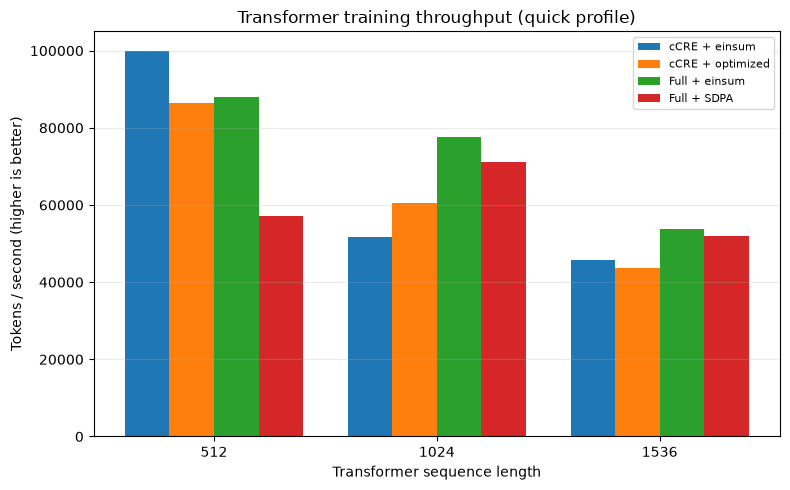

In [8]:
if successful.empty:
    raise RuntimeError("No benchmark case completed successfully")

fig, axes = plt.subplots(1, 2 if DEVICE.type == "cuda" else 1, figsize=(14 if DEVICE.type == "cuda" else 8, 5))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

case_order = [case.label for case in CASES]
colors = dict(zip(case_order, plt.get_cmap("tab10").colors[: len(case_order)]))
x_values = np.arange(len(PROFILE.sequence_lengths), dtype=float)
bar_width = 0.8 / len(case_order)

for case_index, case_label in enumerate(case_order):
    case_rows = successful[successful["case"] == case_label].set_index("sequence_length")
    rows = case_rows.reindex(PROFILE.sequence_lengths)
    positions = x_values - 0.4 + bar_width / 2 + case_index * bar_width
    axes[0].bar(
        positions,
        rows["tokens_per_second"],
        width=bar_width,
        label=case_label,
        color=colors[case_label],
    )

axes[0].set_title(f"Transformer training throughput ({PROFILE_NAME} profile)")
axes[0].set_xlabel("Transformer sequence length")
axes[0].set_ylabel("Tokens / second (higher is better)")
axes[0].set_xticks(x_values, PROFILE.sequence_lengths)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(fontsize=8)

if DEVICE.type == "cuda":
    for case_index, case_label in enumerate(case_order):
        rows = (
            successful[successful["case"] == case_label]
            .set_index("sequence_length")
            .reindex(PROFILE.sequence_lengths)
        )
        positions = x_values - 0.4 + bar_width / 2 + case_index * bar_width
        axes[1].bar(
            positions,
            rows["peak_cuda_memory_mib"],
            width=bar_width,
            label=case_label,
            color=colors[case_label],
        )
    axes[1].set_title("Peak allocated CUDA memory")
    axes[1].set_xlabel("Transformer sequence length")
    axes[1].set_ylabel("MiB (lower is better)")
    axes[1].set_xticks(x_values, PROFILE.sequence_lengths)
    axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

In [9]:
baseline = successful[successful["case"] == "Full + einsum"][
    ["sequence_length", "median_step_ms"]
].rename(columns={"median_step_ms": "full_einsum_step_ms"})
comparison = successful.merge(baseline, on="sequence_length", how="left")
comparison["speedup_vs_full_einsum"] = (
    comparison["full_einsum_step_ms"] / comparison["median_step_ms"]
)

summary_columns = [
    "sequence_length",
    "case",
    "backend",
    "median_step_ms",
    "tokens_per_second",
    "speedup_vs_full_einsum",
    "first_step_s",
]
if DEVICE.type == "cuda":
    summary_columns.append("peak_cuda_memory_mib")

display(
    comparison[summary_columns]
    .sort_values(["sequence_length", "median_step_ms"])
    .round(2)
)

,sequence_length,case,backend,median_step_ms,tokens_per_second,speedup_vs_full_einsum,first_step_s
0,512,cCRE + einsum,einsum,5.12,100009.77,1.14,0.07
2,512,Full + einsum,einsum,5.82,88038.69,1.00,0.04
1,512,cCRE + optimized,masked SDPA fallback,5.93,86314.56,0.98,0.06
3,512,Full + SDPA,SDPA,8.96,57168.91,0.65,0.04
6,1024,Full + einsum,einsum,13.19,77661.31,1.00,0.04
7,1024,Full + SDPA,SDPA,14.41,71079.64,0.92,0.04
5,1024,cCRE + optimized,masked SDPA fallback,16.93,60474.08,0.78,0.05
4,1024,cCRE + einsum,einsum,19.82,51652.93,0.67,0.05
10,1536,Full + einsum,einsum,28.59,53728.68,1.00,0.05
11,1536,Full + SDPA,SDPA,29.50,52071.25,0.97,0.05


## Checks

Interpret the results only when:

- Both paired-output checks above report `close = True`.
- The cCRE optimized backend says `FlexAttention` for the intended CUDA comparison. A CPU/MPS result is useful as a smoke test, but it measures masked SDPA instead.
- The steady-state medians are reasonably separated from run-to-run variation. Increase `timed_steps` if cases are close.
- No case reports an out-of-memory error. OOM is still an important result, but it is not a timing measurement.
- The selected cCRE fraction represents the intended workload. More global positions make the sparse pattern denser and can materially change FlexAttention's advantage.

## Takeaways

The next cell derives a concise conclusion from the current run rather than embedding hardware-specific claims in the notebook.

In [10]:
for sequence_length, group in comparison.groupby("sequence_length", sort=True):
    fastest = group.loc[group["median_step_ms"].idxmin()]
    print(
        f"N={sequence_length}: {fastest['case']} was fastest at "
        f"{fastest['median_step_ms']:.1f} ms/step "
        f"({fastest['speedup_vs_full_einsum']:.2f}x vs Full + einsum)."
    )

if DEVICE.type != "cuda":
    print(
        "\nThis was not a FlexAttention measurement. Re-run on CUDA before drawing "
        "conclusions about the cCRE optimized production path."
    )

N=512: cCRE + einsum was fastest at 5.1 ms/step (1.14x vs Full + einsum).
N=1024: Full + einsum was fastest at 13.2 ms/step (1.00x vs Full + einsum).
N=1536: Full + einsum was fastest at 28.6 ms/step (1.00x vs Full + einsum).

This was not a FlexAttention measurement. Re-run on CUDA before drawing conclusions about the cCRE optimized production path.
